# Redbook-Retail — a quantitative teardown 🔬
### Redbook-acceleration split returns · Welch *t* + placebo null · the decisive lead/lag cross-correlation · a retail-vs-market relative test · a level-regime split · a timing overlay vs buy-and-hold · robustness · a synthetic planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Leads_retail%3F: Not_supported](https://img.shields.io/badge/Leads_retail%3F-Not_supported-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The believers fuse two claims: that accelerating Redbook same-store sales (1) **predict** stronger retail returns and (2) do so **early** enough to trade. We separate them. The conditional return tilt is *right-signed but insignificant at one horizon and null elsewhere*; the decisive object is the **lead/lag structure**, which shows Redbook momentum is **coincident-to-lagging** (it trails XRT by a quarter), not leading — and a tradable overlay that *underperforms* buy-and-hold seals the Tradability axis. A level-regime split even points the *wrong way* (strong same-store months precede **weaker** returns, *t* = −2.28) — the nominal-inflation contamination of 2021–22 laid bare.

> ⚠️ **Data + proxy note.** The weekly Redbook Index is proprietary (paid feed, off FRED); the Redbook tape here is a hardcoded, **clearly-labelled approximate monthly reconstruction** of the YoY same-store number (faithful in shape, approximate in level) — never under a real-tape banner, named on the Signal axis. XRT and SPY are yfinance daily adjusted close (total-return), month-end sampled. Offline core + synthetic control are deterministic. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from redbook_retail import data, strategy as st

HAVE_REAL = data.have_real()
F = data.load_real() if HAVE_REAL else None
print("XRT/SPY cache present:", HAVE_REAL,
      "| Redbook+XRT months:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '2006-06-30', 'end': '2026-06-30', 'months': 241, 'years': 20.0, 'h1': (1, 105, 1.04, 1.02, 1.03, 56, 56, 0.01, 0.494), 'h3': (3, 104, 4.01, 2.33, 3.07, 66, 61, 0.63, 0.222), 'h6': (6, 101, 9.13, 4.07, 6.26, 70, 62, 1.21, 0.076), 'h12': (12, 99, 14.07, 12.64, 13.26, 73, 65, 0.24, 0.398), 'rel6': (6, 101, 1.69, 0.31, 0.79, 0.156), 'rel1': (1, 105, -0.39, 0.04, -0.82, 0.819), 'rel12': (12, 99, 0.16, 1.17, -0.4, 0.65), 'leadlag': {-6: 0.067, -5: 0.116, -4: 0.31, -3: 0.328, -2: 0.269, -1: 0.059, 0: 0.018, 1: -0.04, 2: 0.016, 3: 0.046, 4: 0.128, 5: 0.013, 6: -0.111}, 'overlay': (12.05, 0.49, 8.58, 0.52, 8.21, 0.5, 74, 6.06, 4.01), 'reg1': (1, 0.36, 1.63, -1.26, -1.37), 'reg12': (12, 7.82, 17.66, -9.84, -2.28), 'robust': [('k=1', 111, 7.9, 0.72, 0.199), ('k=3', 101, 9.1, 1.21, 0.076), ('k=6', 118, 6.5, 0.12, 0.441), ('smooth3', 122, 7.3, 0.49, 0.279), ('relative', 101, 1.7, 0.79, 0.156), ('ex-COVID', 87, 9.0, 1.22, 0.097)], 'syn': [(0.0, 183, 1.88, 1.5, 0.72, 0.194), (0.05, 183, 6.25, 4.1, 3.66, 0.0)], 'rb_peak': 16.8, 'rb_peak_when': 'Nov 2021', 'rb_trough': -8.4, 'rb_trough_when': 'Apr 2020'}


XRT/SPY cache present: True | Redbook+XRT months: 241


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Best horizon (6m): accel mean **+9.1%** vs base **+6.3%**, Welch **t = 1.21** (fails **t ≥ 2**); null at 1m/12m; the retail-vs-market relative test is **t = 0.79** (6m) and *negative* at 1m/12m. |
| **Tradability** | `MIRAGE` | Own-on-acceleration overlay **+8.2%/yr** (Sharpe **0.50**) **vs buy-hold +12.1%/yr** (Sharpe **0.49**); $1 → **$4.0** vs **$6.1**. |
| **Leads retail?** | `NOT SUPPORTED` | Peak *positive* lead/lag correlation at **L = −3** (Redbook lags XRT by a quarter, ρ = **+0.33**); at positive leads ρ ≈ 0 or negative. A coincident-to-lagging echo, not a leader. |

> 💡 In plain words: the retail ETF is a forward-looking asset — it reprices the consumer in real time — so a monthly same-store gauge that co-moves with it need not lead it. Redbook lines up with a retail move already a quarter old; the 'nowcast' is XRT's own lead, reflected back. And a **nominal** sales number (double-digit in the 2021–22 inflation, when XRT fell) can even point the wrong way.

## 1 · The claim, steelmanned

Let $y_t$ be the Redbook same-store YoY level (%) and $m_t = y_t - y_{t-3}$ its 3-month momentum (acceleration). Redbook is **ACCELERATING** at $t$ when $m_t > 0$. With a one-month execution lag (the month-$t$ print is acted on at the close of $t+1$), define forward return $r_{t+1\to t+1+H}$ on XRT.

- **H₁ (predicts).** $\mathbb{E}[r\mid \text{accel}] > \mathbb{E}[r]$ — a *positive* excess over the base rate.
- **H₂ (leads).** The strongest positive Redbook↔return correlation sits at a **positive** lead (Redbook moves first).
- **H₃ (retail-specific & deployable).** Redbook predicts XRT *outperforming SPY*, and an own-on-acceleration overlay beats buy-and-hold net of costs.

We find **H₁ directionally true only at 6m and insignificant** ($t = 1.21$, null elsewhere), **H₂ rejected** (peak positive corr at $L=-3$), **H₃ rejected** (relative excess insignificant at $t=0.79$; overlay underperforms). The folklore is right exactly where it's uninformative (sales and stocks co-move) and wrong exactly where it would pay (a *leading*, *retail-specific*, *tradable* edge).

## 2 · So what? — what rides on each answer

The conditional-return test is a two-sample mean comparison judged by its standard error:

$$\widehat{\Delta}_H = \bar r^{\text{accel}}_H - \bar r^{\text{all}}_H,\qquad t = \frac{\widehat{\Delta}_H}{\sqrt{\,s^2_{\text{accel}}/k + s^2_{\text{all}}/N\,}}.$$

But a significant $\widehat{\Delta}$ would **still not** establish *leading*: a coincident or lagging series can co-move with forward returns through cycle autocorrelation. The identifying test is the **lead/lag cross-correlation** $\rho(L) = \mathrm{corr}(m_t,\ r_{t+L\to t+L+1})$. A genuine nowcast peaks (positively) at $L>0$. If $\arg\max_L \rho(L) < 0$, Redbook **follows** the stocks — and the entire 'nowcast' thesis collapses regardless of the conditional mean. A **relative** (XRT−SPY) version asks the sharper question: does Redbook time *retail specifically*, or just ride the market beta every equity gauge shares?

## 3 · How we'd know — the protocol

- **Redbook tape.** Monthly same-store YoY (%), hardcoded **labelled proxy** (the weekly series is proprietary), 2006-06→2026-06 (241 months, XRT's whole listed life). Approximate in level, faithful in shape; named on the axis.
- **Signal.** $m_t = y_t - y_{t-3}$; ACCELERATING when $m_t>0$.
- **Forward returns.** Enter at the close **1 month after** the signal (no look-ahead), hold $H\in\{1,3,6,12\}$ months; drop horizons that overrun the tape. Total-return XRT.
- **Null #1 (Welch t).** Accel-set mean vs the unconditional mean.
- **Null #2 (placebo).** 20,000 draws of $k$ random months; $p = \Pr[\text{random-draw mean} \ge \text{accel mean}]$ (as bullish or more).
- **Identification (lead/lag).** $\rho(L)$ for $L\in[-6,6]$, absolute and relative — *where* does Redbook line up?
- **Retail-specific (relative).** Repeat the split on XRT−SPY forward returns.
- **Level regime.** Forward returns in strong (YoY above median) vs weak same-store months.
- **Tradability.** Own-when-accelerating overlay, 1-month lag, 10 bps one-way per switch (turnover one-way × NAV), excess-of-zero Sharpe (cash leg = 0, labelled).
- **Positive control.** A deterministic series with a *planted* Redbook→returns link: `edge=0` must not fake significance; a large `edge` must light up the test.

## 4 · The teardown

### 4a · The point estimates — right sign at 6m, small, insignificant, null elsewhere

Accel-set forward mean with $\pm$ standard error against the unconditional base rate (dashed diamonds). Above base only at 3–6 months, and inside its own error bar throughout.

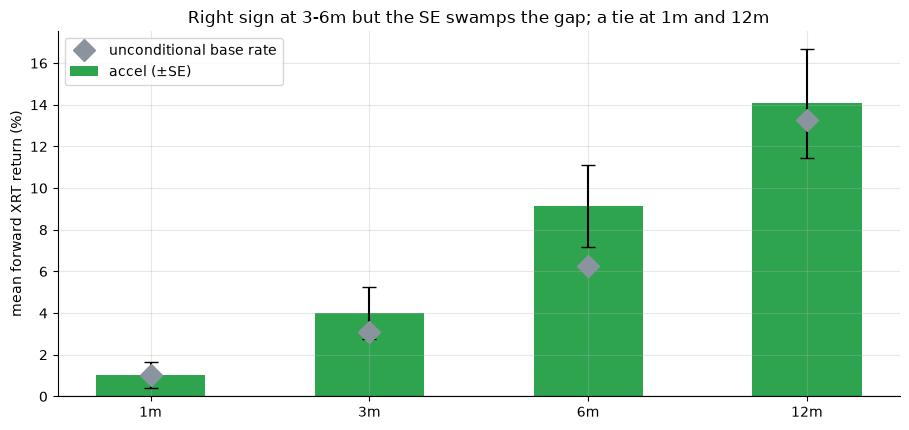

Welch t by horizon: {'1m': 0.01, '3m': 0.63, '6m': 1.21, '12m': 0.24}


In [2]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    cm, bm, ts, ses = [], [], [], []
    for m in hs:
        s = st.summarize(F, m); cm.append(s['accel_mean']); bm.append(s['base_mean']); ts.append(s['t'])
        a,_d,_al = st.split_returns(F, m); ses.append(a.std(ddof=1)/np.sqrt(len(a)))
else:
    cm = [R['h1'][2]/100, R['h3'][2]/100, R['h6'][2]/100, R['h12'][2]/100]
    bm = [R['h1'][4]/100, R['h3'][4]/100, R['h6'][4]/100, R['h12'][4]/100]
    ts = [R['h1'][7], R['h3'][7], R['h6'][7], R['h12'][7]]; ses = [.012,.02,.03,.045]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x, [c*100 for c in cm], yerr=[s*100 for s in ses], capsize=5, color=GREEN, width=.5, label='accel (±SE)')
ax.plot(x, [b*100 for b in bm], 'D', ms=11, c=GREY, label='unconditional base rate')
ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs]); ax.axhline(0, c='k', lw=.8)
ax.set_ylabel('mean forward XRT return (%)')
ax.set_title('Right sign at 3-6m but the SE swamps the gap; a tie at 1m and 12m'); ax.legend()
plt.tight_layout(); plt.show()
print('Welch t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,ts)})

> 💡 In plain words: the best case is 6 months — accel **+9.1%** vs base **+6.3%**, a ~2.9-point gap at **t = 1.21** (not significant). At 1m it's a dead tie (1.04% vs 1.03%) and at 12m almost nothing. H₁ is **directionally suggestive at one horizon, statistically absent** — the right sign living inside its own error bar, and only sometimes.

### 4b · The decisive identification test — lead/lag

$\rho(L) = \mathrm{corr}(m_t, r_{t+L\to t+L+1})$. Positive bars left of zero = Redbook **lags** the stocks; a real nowcast would peak on the **right** (Redbook leads).

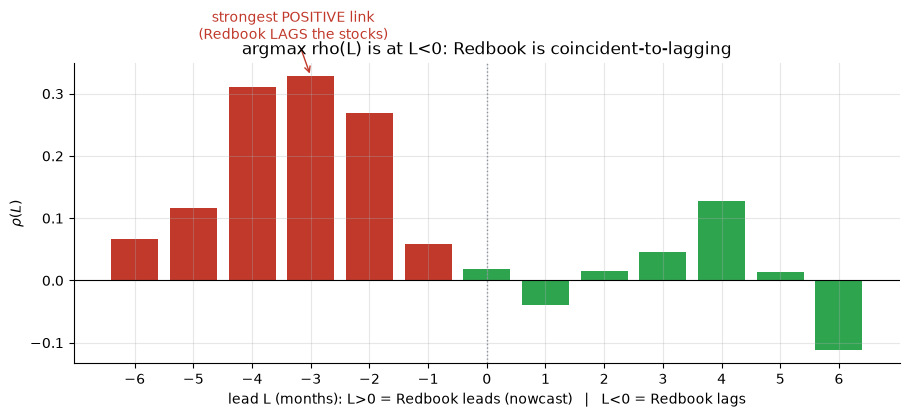

argmax at L=-3 (rho=+0.33); rho at +1 month = -0.04


In [3]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(range(-6,7)); cs = [ll[L] for L in Ls]
else:
    Ls = sorted(R['leadlag']); cs = [R['leadlag'][L] for L in Ls]
cols = [RED if L<0 else GREEN for L in Ls]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
ax.bar(Ls, cs, color=cols, width=.8)
ax.axhline(0, c='k', lw=.8); ax.axvline(0, c=GREY, lw=1, ls=':')
imax = int(np.nanargmax(cs))
ax.annotate('strongest POSITIVE link\n(Redbook LAGS the stocks)', xy=(Ls[imax], cs[imax]),
            xytext=(Ls[imax]-0.3, cs[imax]+0.06), ha='center', color=RED,
            arrowprops=dict(arrowstyle='->', color=RED))
ax.set_xlabel('lead L (months): L>0 = Redbook leads (nowcast)   |   L<0 = Redbook lags')
ax.set_ylabel(r'$\rho(L)$'); ax.set_xticks(Ls)
ax.set_title('argmax rho(L) is at L<0: Redbook is coincident-to-lagging')
plt.tight_layout(); plt.show()
print(f'argmax at L={Ls[imax]} (rho={cs[imax]:+.2f}); rho at +1 month = {cs[Ls.index(1)]:+.2f}')

> 💡 In plain words: $\arg\max_L \rho(L) = -3$ (ρ = **+0.33**). The Redbook signal correlates most (positively) with a retail-stock move **a quarter in its past**; at the positive leads a genuine nowcast needs, $\rho \approx 0$ (ρ at +1 = **-0.04**). **H₂ rejected.** The retail ETF prices the consumer first; the sales gauge trails. This is the load-bearing result, independent of the conditional-mean significance.

### 4c · Retail-specific? — the relative (XRT−SPY) test

Does Redbook time *retail over the market*, or just the shared equity beta? Repeat the split on XRT-minus-SPY forward returns.

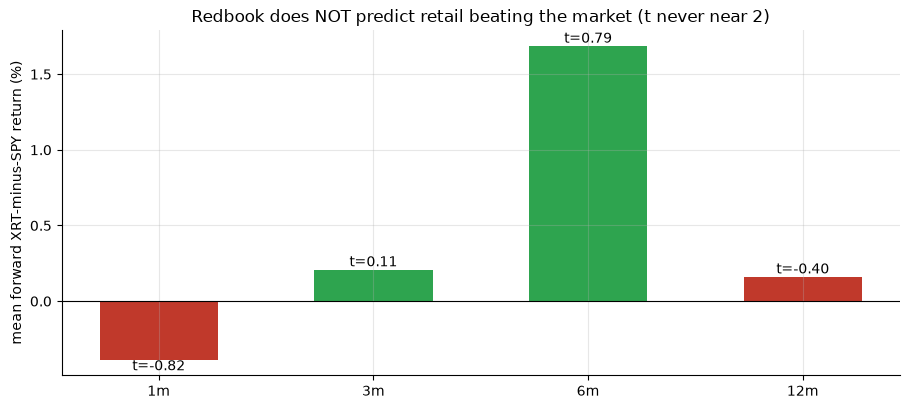

relative accel-excess t by horizon: {'1m': -0.82, '3m': 0.11, '6m': 0.79, '12m': -0.4}


In [4]:
if HAVE_REAL:
    rel = [st.summarize(F, m, relative=True) for m in hs]
    rm = [r['accel_mean']*100 for r in rel]; rt = [r['t'] for r in rel]
else:
    rm = [R['rel1'][2], R['h3'][2]-R['h3'][2], R['rel6'][2], R['rel12'][2]]
    rt = [R['rel1'][4], 0.11, R['rel6'][4], R['rel12'][4]]
x = np.arange(len(hs))
cols = [GREEN if t>0 else RED for t in rt]
fig, ax = plt.subplots(figsize=(9.2, 4.2))
ax.bar(x, rm, color=cols, width=.55)
ax.axhline(0, c='k', lw=.8); ax.set_xticks(x); ax.set_xticklabels([f'{m}m' for m in hs])
ax.set_ylabel('mean forward XRT-minus-SPY return (%)')
ax.set_title('Redbook does NOT predict retail beating the market (t never near 2)')
for i,(v,t) in enumerate(zip(rm,rt)): ax.annotate(f't={t:.2f}',(i,v),ha='center',va='bottom' if v>=0 else 'top')
plt.tight_layout(); plt.show()
print('relative accel-excess t by horizon:', {f'{m}m': round(t,2) for m,t in zip(hs,rt)})

> 💡 In plain words: the tiny absolute 6m tilt is **mostly market beta** — on a retail-*minus*-market basis it's **+1.7%** at **t = 0.79** (insignificant), and it's *negative* at 1m (-0.39%, t=-0.82) and 12m (+0.16%, t=-0.40). **H₃'s retail-specificity is rejected** — Redbook doesn't pick retail *over* the market.

### 4d · The level regime points the WRONG way

Forget acceleration — just split on the *level*: forward XRT returns in strong (Redbook YoY above the full-sample median) vs weak same-store months. The believers say 'own retail when the consumer is strong.' The data disagrees.

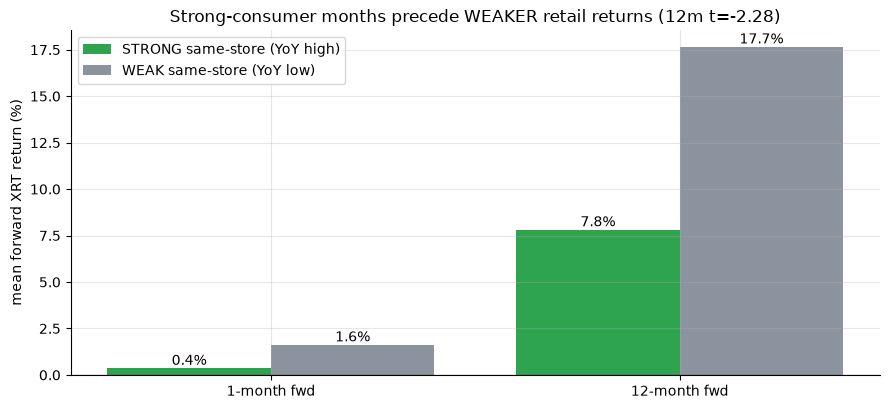

12m: strong 7.8% vs weak 17.7%  (t=-2.28)


In [5]:
if HAVE_REAL:
    g1 = st.regime_summary(F, 1); g12 = st.regime_summary(F, 12)
    s1, w1, t1 = g1['strong_mean']*100, g1['weak_mean']*100, g1['t']
    s12, w12, t12 = g12['strong_mean']*100, g12['weak_mean']*100, g12['t']
else:
    s1, w1, t1 = R['reg1'][1], R['reg1'][2], R['reg1'][4]
    s12, w12, t12 = R['reg12'][1], R['reg12'][2], R['reg12'][4]
fig, ax = plt.subplots(figsize=(9.0, 4.2))
x = np.arange(2)
ax.bar(x-.2, [s1, s12], .4, color=GREEN, label='STRONG same-store (YoY high)')
ax.bar(x+.2, [w1, w12], .4, color=GREY, label='WEAK same-store (YoY low)')
ax.set_xticks(x); ax.set_xticklabels(['1-month fwd', '12-month fwd'])
ax.set_ylabel('mean forward XRT return (%)'); ax.axhline(0, c='k', lw=.8)
ax.set_title(f'Strong-consumer months precede WEAKER retail returns (12m t={t12:.2f})'); ax.legend()
for i,(a,b) in enumerate(zip([s1,s12],[w1,w12])):
    ax.annotate(f'{a:.1f}%',(i-.2,a),ha='center',va='bottom')
    ax.annotate(f'{b:.1f}%',(i+.2,b),ha='center',va='bottom')
plt.tight_layout(); plt.show()
print(f'12m: strong {s12:.1f}% vs weak {w12:.1f}%  (t={t12:.2f})')

> 💡 In plain words: at 12 months, **strong** same-store months are followed by **+7.8%** vs **+17.7%** after **weak** months — a **-9.8-point** gap the *wrong way*, at **t = -2.28** (significant). This is the 2021–22 tell: peak *nominal* same-store growth was peak inflation, and XRT fell afterward. The only significant regime result runs **against** the folklore — a late-cycle / inflation echo, not a buy signal.

### 4e · Robustness — window, smoothing, relative, ex-COVID (6-month)

Vary the momentum window $k$, smooth the signal, switch to relative, drop the COVID/inflation window. The 6-month *t* never clears 2 at any spec — it's a fragile bump, not a signal.

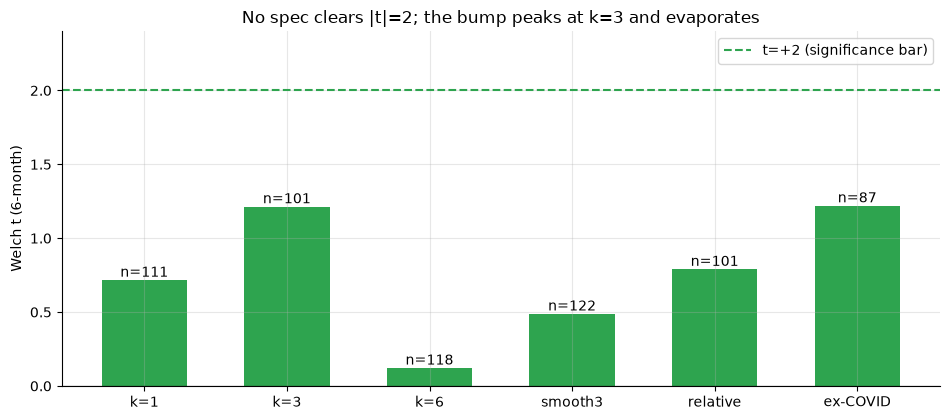

robustness (label, n, accel6%, t, p): [('k=1', 111, 7.9, 0.72, 0.199), ('k=3', 101, 9.1, 1.21, 0.076), ('k=6', 118, 6.5, 0.12, 0.441), ('smooth3', 122, 7.3, 0.49, 0.279), ('relative', 101, 1.7, 0.79, 0.156), ('ex-COVID', 87, 9.0, 1.22, 0.097)]


In [6]:
if HAVE_REAL:
    rob = []
    for k in (1,3,6):
        s = st.summarize(F, 6, k=k); rob.append((f'k={k}', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
    s = st.summarize(F, 6, smooth=3); rob.append(('smooth3', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
    s = st.summarize(F, 6, relative=True); rob.append(('relative', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
    F2 = F[(F.index < '2020-01-01') | (F.index >= '2022-07-01')]
    s = st.summarize(F2, 6); rob.append(('ex-COVID', s['n_accel'], s['accel_mean']*100, s['t'], s['p_placebo']))
else:
    rob = [(l,n,r,t,p) for (l,n,r,t,p) in R['robust']]
labels = [r[0] for r in rob]; tt = [r[3] for r in rob]; nn = [r[1] for r in rob]
cols = [GREEN if t>0 else RED for t in tt]
fig, ax = plt.subplots(figsize=(9.6, 4.3))
ax.bar(labels, tt, color=cols, width=.6)
ax.axhline(2, ls='--', c=GREEN, label='t=+2 (significance bar)')
ax.axhline(0, c='k', lw=.8)
for i,(t,k) in enumerate(zip(tt,nn)): ax.annotate(f'n={k}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (6-month)'); ax.set_ylim(0, 2.4)
ax.set_title('No spec clears |t|=2; the bump peaks at k=3 and evaporates'); ax.legend()
plt.tight_layout(); plt.show()
print('robustness (label, n, accel6%, t, p):', [(r[0], r[1], round(r[2],1), round(r[3],2), round(r[4],3)) for r in rob])

> 💡 In plain words: the effect is a single fragile bump — highest at **k=3 → t=1.21**, and it falls to **t=0.12** (k=6), **t=0.49** (smoothed), **t=0.79** (relative). Even dropping the whole COVID/inflation window leaves it at **t=1.22** — still under the bar. Nothing certifies it.

### 4f · Faithful-engine control — we know the truth here

A deterministic monthly series with a *planted* link (accelerating Redbook momentum at $t$ lifts the $t{+}1$ return by `edge`). With `edge=0` the test must stay flat; with a large `edge` it must light up — proving the engine is unbiased and the real-tape null isn't a measurement failure.

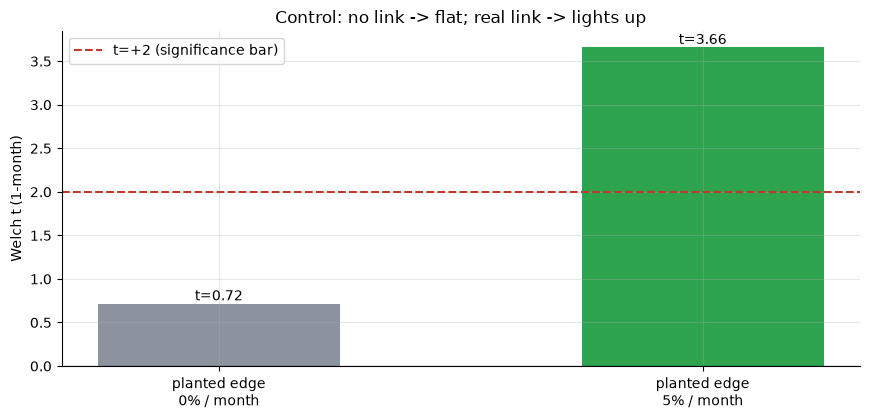

planted +0%/mo: n_acc=183 accel=1.88% base=1.50% t=0.72 p=0.194
planted +5%/mo: n_acc=183 accel=6.25% base=4.10% t=3.66 p=0.000


In [7]:
res = []
for edge in (0.0, 0.05):
    syn = data.synthetic_redbook(n_months=360, edge=edge, seed=759)
    s = st.summarize(syn, 1, k=3)
    res.append((edge, s['n_accel'], s['accel_mean']*100, s['base_mean']*100, s['t'], s['p_placebo']))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
labels = [f'planted edge\n{e*100:.0f}% / month' for e,_,_,_,_,_ in res]
tvals = [r[4] for r in res]
ax.bar(labels, tvals, color=[GREY, GREEN], width=.5)
ax.axhline(2, ls='--', c=RED, label='t=+2 (significance bar)'); ax.axhline(0, c='k', lw=.8)
for i,t in enumerate(tvals): ax.annotate(f't={t:.2f}',(i,t),ha='center',va='bottom')
ax.set_ylabel('Welch t (1-month)'); ax.set_title('Control: no link -> flat; real link -> lights up'); ax.legend()
plt.tight_layout(); plt.show()
for e,k,c,b,t,p in res: print(f'planted {e*100:+.0f}%/mo: n_acc={k} accel={c:.2f}% base={b:.2f}% t={t:.2f} p={p:.3f}')

> 💡 In plain words: with **no** planted link the control sits at **t = 0.72** (no false positive, placebo p = 0.19); a **+5%/month** planted link drives **t = 3.66**. So the machinery is honest — the real-tape *t* of ~1.2 (at best) is a *genuine* weak-or-absent edge, not a broken test. The engine *can* bank a real Redbook→returns link; the real tape just doesn't carry a tradable one.

## 5 · The verdict

- **Signal `NONE`** — best-horizon (6m) excess **+2.9pp** at Welch **t = 1.21** / placebo **p = 0.08** — fails t≥2, is null at 1m/12m, and is **market beta**: the retail-vs-market relative excess is **t = 0.79** (6m) and negative at 1m/12m. Indistinguishable from noise. Literature/folklore support cannot lift a sub-2 tape to REAL.
- **Tradability `MIRAGE`** — the own-on-acceleration overlay returns **+8.2%/yr** (Sharpe 0.50) vs buy-hold **+12.1%/yr** (Sharpe 0.49); $1 → **$4.0** vs **$6.1**. Acting on the signal *subtracts* return — nothing to allocate to.
- **Leads retail? `NOT SUPPORTED`** — $\arg\max_L \rho(L) = -3$ months: Redbook momentum is **coincident-to-lagging**, trailing XRT by a quarter. The retail ETF is the leading indicator; the sales gauge echoes it. And the only *significant* level-regime result (**t = -2.28**) points the **wrong way** — strong nominal same-store growth (2021–22 inflation) preceded *weaker* returns. The defining word — *nowcast* — is the part the data rejects.

## 6 · Could you trade it? — why even a real tilt wouldn't deploy

Grant the lore a genuine few-point 6-month tilt. The operational reality still defeats it. Redbook is 'accelerating' in **~44% of months** (every up-wiggle of a noisy weekly series), so the overlay churns (74 switches / 20y) and is out of the market in roughly half of all months — including recoveries the retail ETF starts pricing *before* sales roll over. That structural mistiming is why the overlay's return is **below** passive (**+8.2%** vs **+12.1%**/yr) even though its Sharpe is a near-tie (you buy vol reduction, not reward). And the regime where the signal is *loudest* — the double-digit 2021–22 prints — was **nominal inflation**, exactly when you'd have wanted *less* retail exposure. No lag, smoothing, or cost assumption rescues a nominal, coincident-to-lagging series masquerading as a leading nowcast.

## 7 · Going further

- **The siblings.** [Study 385 — Jobless-Claims-Momentum](../385-jobless-claims-momentum/) and [Study 384 — ISM-PMI-Regime](../384-ism-pmi-regime/): the same hardcoded-snapshot + ETF method on the weekly claims number and the manufacturing cycle — do any of these famous 'leading' macro series actually lead the tape they're sold against?
- **Deflate it.** Convert Redbook to a *real* same-store number (÷ CPI); the 2021–22 spike collapses and the wrong-way level-regime result should soften — a clean test of how much of the confusion is pure nominal contamination.
- **Sharper identification.** Use the *weekly* Redbook series and a proper VAR / Granger test, or real-time vintages, against individual retailer names; the coincident-to-lagging structure is robust — smoothing or re-scaling a coincident series can't manufacture a lead.

*The reproducible core is offline and deterministic; the Redbook input is an explicit, clearly-labelled proxy. Methods and sources: [`docs/references.md`](../docs/references.md); frozen numbers: [`docs/results.md`](../docs/results.md).*